In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import TotalVariationRecon, L1WaveletRecon
from scipy.io import savemat, loadmat
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.signal import butter,filtfilt


## My files
from ksp_plot_helpers import plot_ksp_data_multichannel, find_and_plot_acquired_region
from raw_data_utils import get_kspace_data, get_TR
from resp_signal_functions import resp_signal_all_slices, resp_signal_single_slice, resp_signal_center_sample_single_slice
from resp_signal_plot_functions import *
import gating_functions
from pca_helper import pca_resp_signal
import save_data_helpers
import recon_plot_helpers

In [2]:
import numpy as np
import os

def load_data(filepath, shape):
    """
    Load data saved by save_data function.
    """
    dtype = np.float32
    
    # Read binary data
    with open(filepath, 'rb') as f:
        data_flat = np.fromfile(f, dtype=dtype)
    
    # Determine the shape after axis movement (if it happened during save)
    if len(shape) > 3:
        # Stored shape has gate dimension at the end
        stored_shape = shape[1:] + (shape[0],)
    else:
        stored_shape = shape
    
    # Reshape using Fortran order (same as used during save)
    data = np.reshape(data_flat, stored_shape, order='F')
    
    # Move gate axis back to first position if needed
    if len(shape) > 3:
        data = np.moveaxis(data, -1, 0)
    
    return data

    # help function to create interpolation operators:
def motion_vec_field_2_op_list(mvf,m):
    
        xp = np

        # ensure border of MVF is all zeros:
        if True:
            mvf[:,0,...]=0
            mvf[:,-1,...]=0
            mvf[:,:,0,...]=0
            mvf[:,:,-1,...]=0
            mvf[:,:,:,0,...]=0
            mvf[:,:,:,-1,...]=0

        # asserting mvf is 4d, with time/gate dimension in first dim:
        op_list=[]
        in_x = xp.arange(0,m[0],1)
        in_y = xp.arange(0,m[1],1)
        in_z = xp.arange(0,m[2],1)
        x,y,z = xp.meshgrid(in_x,in_y,in_z,indexing='ij')
        base_grid = xp.stack((x,y,z),axis=-1)
        for gate in range(mvf.shape[0]):
            op_list.append(sp.linop.Interpolate(tuple(m),base_grid+mvf[gate,...]))

        return op_list

def load_mvfs(filepath, num_gates, mvf_shape):
    dtype = np.float32
    
    # Read binary data
    with open(filepath, 'rb') as f:
        mvf_flat = np.fromfile(f, dtype=dtype)
    
    mvf = np.reshape(mvf_flat, (*mvf_shape, 3, num_gates), order='F')
    mvf = np.moveaxis(mvf, -1, 0)
    return mvf

In [3]:
num_spokes = 50

(5, 58, 512, 512)


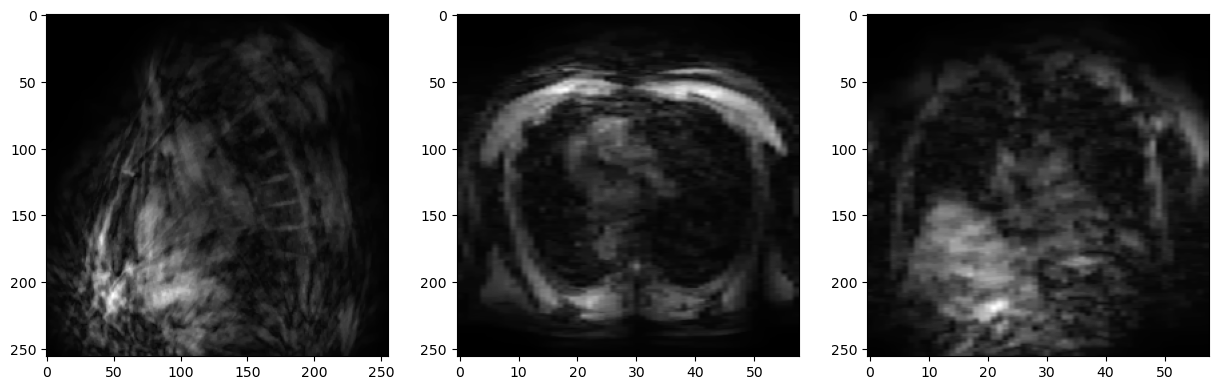

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [4]:
base_dir_recons = f"//data/lilianae/ADMM_results/optical_flow/opt_flow_{num_spokes}sp_lam_0.001/indep_recons_000_abs.v"
# base_dir_recons = f'/data/lilianae/ADMM_results/400sp_George/recon_output/original_z_rho_0.01_beta_0.0001_lam_0.001/indep_recons_000_abs.v'
shape = (5, 58, 512, 512)
indep_recons = load_data(base_dir_recons, shape=shape)
print(indep_recons.shape)
oshape = (58, 256, 256)
indep_recons_cropped = recon_plot_helpers.crop_xy_dimension(indep_recons[3], oshape=oshape)
recon_plot_helpers.plot_recons_all_axes(np.abs(indep_recons_cropped))

In [5]:
mvf_shape = (58, 512, 512) 
img_shape = (58, 512, 512) 
num_gates=5

base_dir_mvf = f'/data/lilianae/ADMM_results/optical_flow/opt_flow_{num_spokes}sp/S_indep_recon.mvf'
base_dir_mvf_inv = f'/data/lilianae/ADMM_results/optical_flow/opt_flow_{num_spokes}sp/S_indep_recons_inv.mvf'

tmp_mvf = load_mvfs(base_dir_mvf, num_gates=num_gates, mvf_shape=mvf_shape)
tmp_mvf_inv = load_mvfs(base_dir_mvf_inv, num_gates=num_gates, mvf_shape=mvf_shape)

Ss_inv = motion_vec_field_2_op_list(tmp_mvf_inv, img_shape)
Ss = motion_vec_field_2_op_list(tmp_mvf,img_shape)
print(Ss_inv)

[<[58, 512, 512]x[58, 512, 512]> Interpolate Linop>, <[58, 512, 512]x[58, 512, 512]> Interpolate Linop>, <[58, 512, 512]x[58, 512, 512]> Interpolate Linop>, <[58, 512, 512]x[58, 512, 512]> Interpolate Linop>, <[58, 512, 512]x[58, 512, 512]> Interpolate Linop>]


In [ ]:
# mvf_shape = (58, 512, 512) 
# img_shape = (58, 512, 512) 
# num_gates=5

# base_dir_mvf = f'/data/lilianae/ADMM_results/400sp_George/recon_output/original_z_rho_0.01_beta_0.0001_lam_0.001/S_indep_recon.mvf'
# base_dir_mvf_inv = f'/data/lilianae/ADMM_results/400sp_George/recon_output/original_z_rho_0.01_beta_0.0001_lam_0.001/S_indep_recons_inv.mvf'

# tmp_mvf = load_mvfs(base_dir_mvf, num_gates=num_gates, mvf_shape=mvf_shape)
# tmp_mvf_inv = load_mvfs(base_dir_mvf_inv, num_gates=num_gates, mvf_shape=mvf_shape)

# Ss_inv = motion_vec_field_2_op_list(tmp_mvf_inv, img_shape)
# Ss = motion_vec_field_2_op_list(tmp_mvf,img_shape)
# print(Ss_inv)

In [6]:
# This is probably what you want for final reconstruction
# Warp all gates to target frame and average
num_gates = 5
img_shape = (58, 512, 512)
motion_corrected_avg = np.zeros(img_shape, dtype=cp.complex64)

for i in range(num_gates):
    # Warp each gate to target coordinate frame
    warped = Ss_inv[i](indep_recons[i])
    motion_corrected_avg += warped

motion_corrected_avg /= num_gates

# Save for comparison with lambda
print(motion_corrected_avg.shape)

(58, 512, 512)


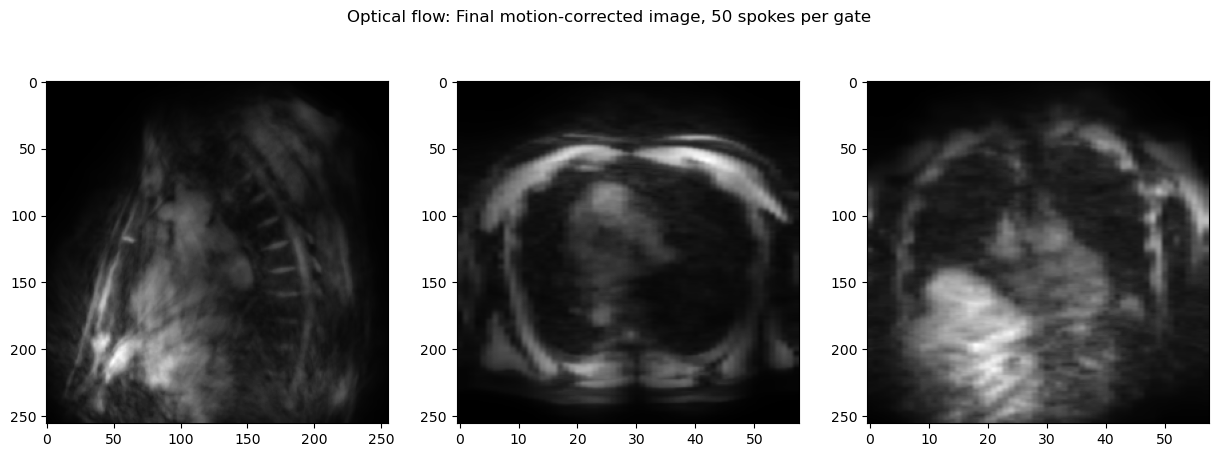

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [7]:
oshape=(58, 256, 256)
moco_avg_cropped = recon_plot_helpers.crop_xy_dimension(motion_corrected_avg, oshape)
recon_plot_helpers.plot_recons_all_axes(np.abs(moco_avg_cropped), z_idx=58//2, 
                                        title=rf"Optical flow: Final motion-corrected image, 50 spokes per gate")

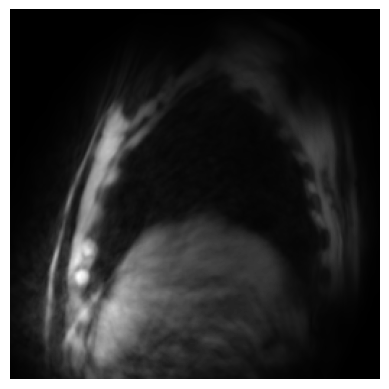

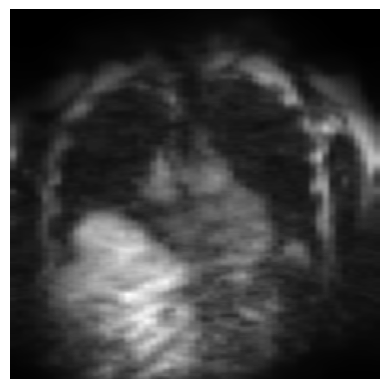

In [8]:
recon_plot_helpers.plot_recon_single_axis(moco_avg_cropped, slice_axis=0, slice_idx=40)
recon_plot_helpers.plot_recon_single_axis(moco_avg_cropped, slice_axis=2)

In [ ]:
# save_data_helpers.write_pickle(moco_avg_cropped, '/home/lilianae/projects/naf_clean/ismrm_figs/lam_abs_cropped_opt_flow_50sp.pkl')